In [0]:
!pip install -U \
    category-encoders \
    # cffi==1.16.0 \
    cloudpickle==3.0.0 \
    nltk==3.9.2 \
    defusedxml==0.7.1 \
    graphviz==0.20.3 \
    holidays==0.54 \
    lightgbm==4.5.0 \
    # lz4==4.3.3 \
    matplotlib==3.9.2 \
    psutil==5.9.8 \
    pyarrow==15.0.2 \
    optuna \
    sentence-transformers

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
!pip install sentence-transformers

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
!pip install emoji nltk keybert

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
!pip install hdbscan umap

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
train_df = pd.read_csv(
    "/Workspace/Users/saurabh.prajapati@tvsmotor.com/Project/data/raw/train.tsv",
    sep='\t',
    names=[
        "customer_identifier",
        "medicine_name",
        "rating",
        "effectiveness",
        "side_effects",
        "illness",
        "review_benefits",
        "review_sideEffects",
        "review_overall"
    ],
    header=None
)


In [0]:
import pandas as pd
test_df = pd.read_csv(
    "/Workspace/Users/saurabh.prajapati@tvsmotor.com/Project/data/raw/test.tsv",
    sep='\t',
    names=[
        "customer_identifier",
        "medicine_name",
        "rating",
        "effectiveness",
        "side_effects",
        "illness",
        "review_benefits",
        "review_sideEffects",
        "review_overall"
    ],
    header=None
)

In [0]:
df=pd.concat([train_df,test_df],axis=0)

In [0]:
df.isnull().sum()

customer_identifier    0
medicine_name          0
rating                 0
effectiveness          0
side_effects           0
illness                1
review_benefits        0
review_sideEffects     2
review_overall         8
dtype: int64

In [0]:
mode_illness = df['illness'].mode()[0]
df['illness'] = df['illness'].fillna(mode_illness)
df['review_benefits'] = df['review_benefits'].fillna("")
df['review_sideEffects'] = df['review_sideEffects'].fillna("")
df['review_overall'] = df['review_overall'].fillna("")
df['rating']=df['rating'].astype(str)

In [0]:
review_template = (
    "review_benefits: {review_benefits}\n"
    "review_sideEffects: {review_sideEffects}\n"
    "review_overall: {review_overall}  \n"
    "rating: {rating}  \n"
)

df['combined_feats'] = df.apply(lambda row: review_template.format(**row), axis=1)


In [0]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('pritamdeka/S-PubMedBert-MS-MARCO')
text_embeddings = model.encode(df["combined_feats"].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/130 [00:00<?, ?it/s]

In [0]:
df.head()

,customer_identifier,medicine_name,rating,effectiveness,side_effects,illness,review_benefits,review_sideEffects,review_overall,combined_feats,cohort,review_overall_cleaned,review_sideEffects_cleaned,review_benefits_cleaned
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ...",review_benefits: slowed the progression of lef...,2,monitor blood pressure weight ass resolution f...,cough hypotension proteinuria impotence renal ...,slowed progression left ventricular dysfunctio...
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest...",review_benefits: Although this type of birth c...,2,hate birth control would suggest anyone,heavy cycle cramp hot flash fatigue lasting cy...,although type birth control con pro help cramp...
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...,review_benefits: I was used to having cramps s...,2,pill onset menstrual cramp hour needed day cra...,heavier bleeding clotting normal,cramp badly would leave balled bed least day p...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...,review_benefits: The acid reflux went away for...,2,given prilosec mg eating duration month,constipation dry mouth mild dizziness would go...,acid went away month day heartburn soon began ...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above,review_benefits: I think that the Lyrica was s...,2,see,felt extremely drugged dopey could drive also ...,think lyrica help pain side effect severe


In [0]:
import seaborn as sns

/home/spark-86c61304-475c-421b-9e53-d7/.ipykernel/1804/command-7614988294258746-3842863663:8: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



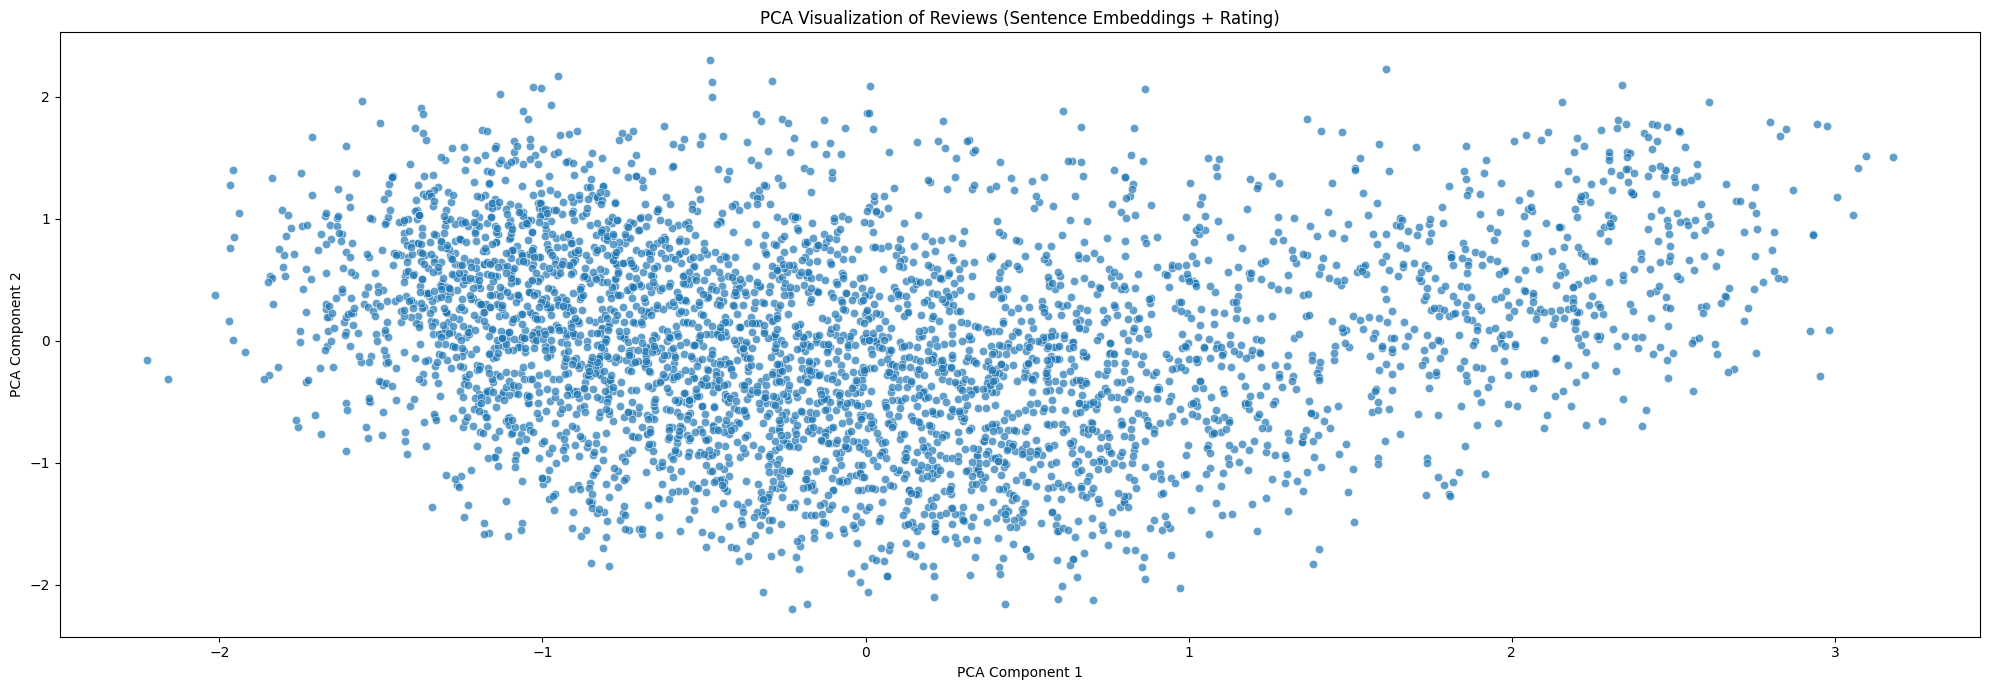

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_vis = pca.fit_transform(text_embeddings)

plt.figure(figsize=(20, 7))
sns.scatterplot(
    x=X_vis[:, 0],
    y=X_vis[:, 1],
    palette="viridis",
    alpha=0.7
)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title("PCA Visualization of Reviews (Sentence Embeddings + Rating)")
plt.tight_layout()
display(plt.gcf())
plt.close()

In [0]:
# ================================
# K-Means Clustering Optimization
# ================================

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler



# -------------------------
best_k = 3  # ← Change based on the plots (peak silhouette or elbow bend)
kmeans = KMeans(n_clusters=best_k, random_state=42)
df["cohort"] = kmeans.fit_predict(text_embeddings)

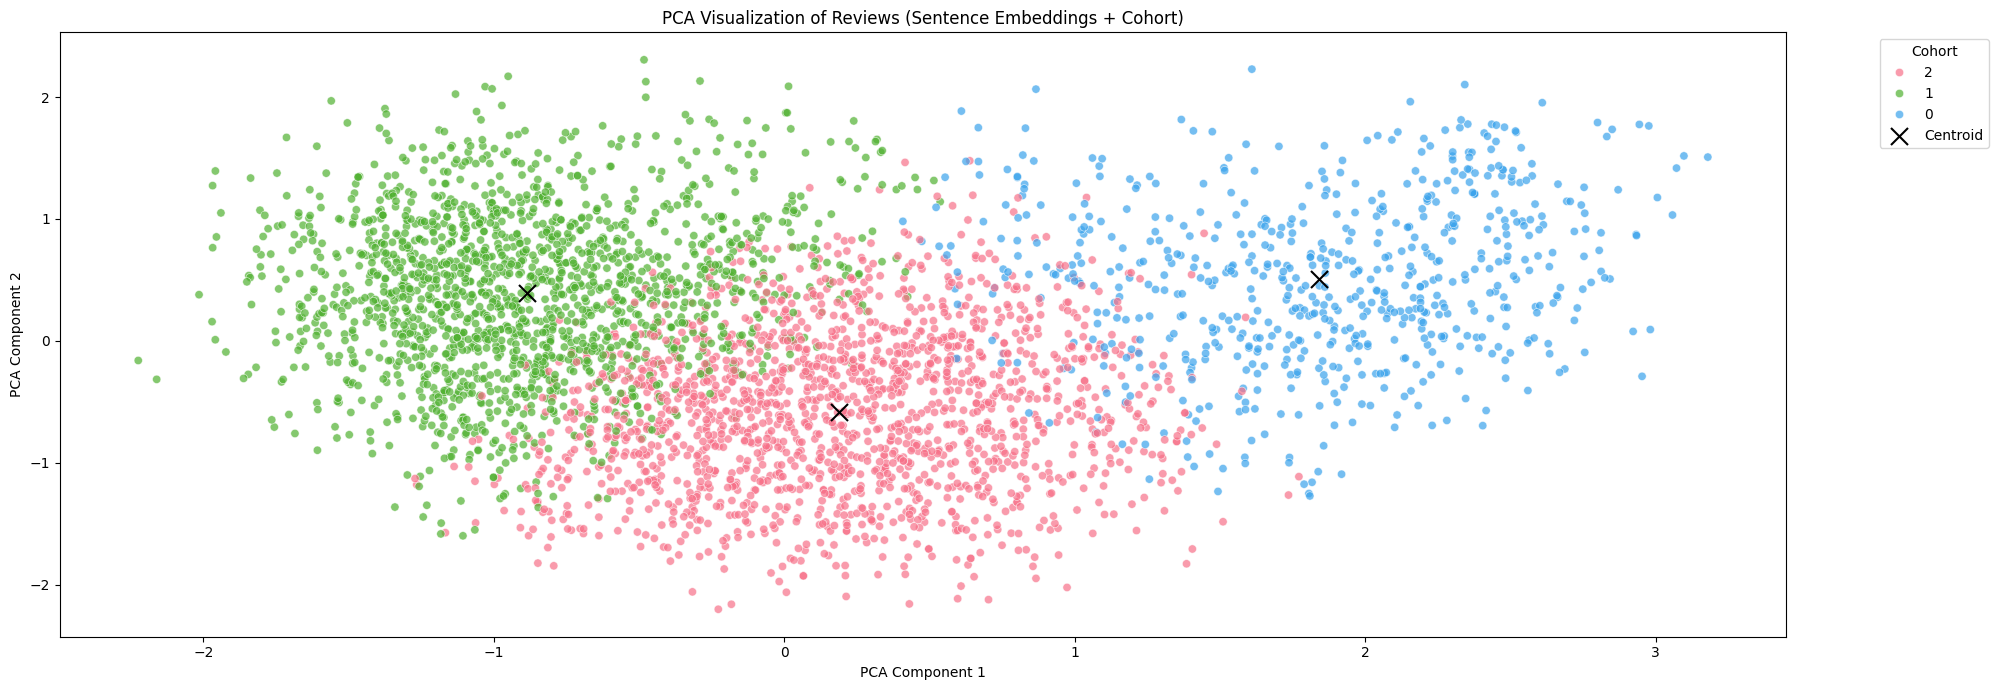

In [0]:
from sklearn.decomposition import PCA
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

features_for_pca = text_embeddings

pca = PCA(n_components=2)
X_vis = pca.fit_transform(features_for_pca)

# Compute centroids in PCA space
kmeans = KMeans(n_clusters=df["cohort"].nunique(), random_state=42)
kmeans.fit(features_for_pca)
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(20, 7))
palette = sns.color_palette("husl", df["cohort"].nunique())
sns.scatterplot(
    x=X_vis[:, 0],
    y=X_vis[:, 1],
    hue=df["cohort"].astype(str),
    palette=palette,
    alpha=0.7,
    legend="full"
)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='x',
    s=150,
    c='black',
    label='Centroid'
)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title("PCA Visualization of Reviews (Sentence Embeddings + Cohort)")
plt.legend(title="Cohort", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
display(plt.gcf())
plt.close()

In [0]:
df.head()

,customer_identifier,medicine_name,rating,effectiveness,side_effects,illness,review_benefits,review_sideEffects,review_overall,combined_feats,cohort,review_overall_cleaned,review_sideEffects_cleaned,review_benefits_cleaned
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ...",review_benefits: slowed the progression of lef...,2,monitor blood pressure weight ass resolution f...,cough hypotension proteinuria impotence renal ...,slowed progression left ventricular dysfunctio...
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest...",review_benefits: Although this type of birth c...,2,hate birth control would suggest anyone,heavy cycle cramp hot flash fatigue lasting cy...,although type birth control con pro help cramp...
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...,review_benefits: I was used to having cramps s...,2,pill onset menstrual cramp hour needed day cra...,heavier bleeding clotting normal,cramp badly would leave balled bed least day p...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...,review_benefits: The acid reflux went away for...,2,given prilosec mg eating duration month,constipation dry mouth mild dizziness would go...,acid went away month day heartburn soon began ...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above,review_benefits: I think that the Lyrica was s...,2,see,felt extremely drugged dopey could drive also ...,think lyrica help pain side effect severe


In [0]:
df['rating']=df['rating'].astype(int)

In [0]:
cluster_summary = (
    df.groupby("cohort")
      .agg({
          "rating": ["mean", "count"],
          "medicine_name": lambda x: x.value_counts().index[0],
          "illness": lambda x: x.value_counts().index[0]
      })
)
cluster_summary.columns = ["avg_rating", "count", "top_medicine", "top_illness"]
display(cluster_summary)

avg_rating,count,top_medicine,top_illness
7.097744360902255,665,retin-a,acne
7.174585002862049,1747,lexapro,depression
6.658001155401502,1731,nexium,birth control


In [0]:
cluster_summary.to_dict()

{'avg_rating': {0: 7.097744360902255,
  1: 7.174585002862049,
  2: 6.658001155401502},
 'count': {0: 665, 1: 1747, 2: 1731},
 'top_medicine': {0: 'retin-a', 1: 'lexapro', 2: 'nexium'},
 'top_illness': {0: 'acne', 1: 'depression', 2: 'birth control'}}

In [0]:
import re, nltk ,emoji
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
additional_stopwords = {
    "drug", "medicine", "tablet", "doctor", "patient", "review_benefits", "review_sideEffects","review_sideeffects","review_benefits"
    "review_overall", "illness","medicine_name","symptom","reflux","side_effects"
"mg", "day", "night","pill",
 "take", "took", "used", "taking", "pill", "one", "review",
    "dose", "dosage", "medication", "treatment", "therapy", "prescribed", "prescription", 
    "prescribe", "physician", "med", "antibiotic",  "application", "apply", "use", 
    "using", "take", "taken", "stop", "stopped", "started", "starting", "start", "continue",
    "continued", "course", "treat", "treated", "treating", "dos", "mcg", "tab", "daily", 
    "nightly", "bedtime", "morning", "evening", "hour", "per", "pm", "qd", "weekly", "month",
    "week", "year", "night", "time", "two", "three", "four", "five", "every", "twice", "long",
    "within", "since", "around", "last", "next", "ago", "short","month",
    "january", "february", "march", "april", "may", "june", "july", "august", "september",
    "october", "november", "december", "jan", "feb", "mar", "apr", "jun", "jul", "aug", "sep",
    "sept", "oct", "nov", "dec","effect", "pill", "tablet"
}
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english')).union(additional_stopwords)
lemmatizer = WordNetLemmatizer()

# ----------------------------------------------------------------
# 🔹 3. Text Preprocessor Function
# ----------------------------------------------------------------
def preprocess_text_fast(text):
    if not isinstance(text, str):
        return ""
    text = emoji.demojize(text, language='en')
    text = text.lower().strip()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return " ".join(words)
df["review_overall_cleaned"] = df["review_overall"].apply(preprocess_text_fast)
df["review_sideEffects_cleaned"] = df["review_sideEffects"].apply(preprocess_text_fast)
df["review_benefits_cleaned"] = df["review_benefits"].apply(preprocess_text_fast)


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/spark-86c61304-475c-421b-9e53-d7/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/spark-86c61304-475c-421b-9e53-d7/nltk_data...


In [0]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)
X_tfidf = vectorizer.fit_transform(df["review_overall_cleaned"])

terms = np.array(vectorizer.get_feature_names_out())
cluster_keywords = {}

for c in sorted(df["cohort"].unique()):
    mask = (df["cohort"] == c).values  # Convert to numpy array
    cluster_docs = X_tfidf[mask]
    mean_tfidf = np.asarray(cluster_docs.mean(axis=0)).ravel()
    top_idx = mean_tfidf.argsort()[-10:][::-1]
    cluster_keywords[c] = terms[top_idx]

for c, words in cluster_keywords.items():
    print(f"Cluster {c}: {', '.join(words)}")

Cluster 0: skin, face, acne, cream, applied, retin, area, dry, month, mg
Cluster 1: mg, depression, year, month, sleep, effect, needed, anxiety, increased, feel
Cluster 2: mg, day, pain, time, effect, week, hour, pill, year, tablet


In [0]:
df.columns

Index(['customer_identifier', 'medicine_name', 'rating', 'effectiveness',
       'side_effects', 'illness', 'review_benefits', 'review_sideEffects',
       'review_overall', 'combined_feats', 'cohort', 'review_overall_cleaned',
       'review_sideEffects_cleaned', 'review_benefits_cleaned'],
      dtype='object')

In [0]:
from keybert import KeyBERT
kw_model = KeyBERT()

for c in sorted(df["cohort"].unique()):
    print(f"\nCluster {c}:")
    # review_overall_cleaned
    text_overall = " ".join(df.loc[df["cohort"] == c, "illness"].tolist())
    keywords_overall = kw_model.extract_keywords(text_overall, keyphrase_ngram_range=(1, 2), stop_words='english', top_n=10)
    print(f"  illness keywords: {[k[0] for k in keywords_overall]}")

    text_overall = " ".join(df.loc[df["cohort"] == c, "medicine_name"].tolist())
    keywords_overall = kw_model.extract_keywords(text_overall, keyphrase_ngram_range=(1, 2), stop_words='english', top_n=10)
    print(f"  medicine_name keywords: {[k[0] for k in keywords_overall]}")

    text_overall = " ".join(df.loc[df["cohort"] == c, "review_overall_cleaned"].tolist())
    keywords_overall = kw_model.extract_keywords(text_overall, keyphrase_ngram_range=(1, 2), stop_words='english', top_n=10)
    print(f"  review_overall_cleaned keywords: {[k[0] for k in keywords_overall]}")
    # review_sideEffects_cleaned
    text_side = " ".join(df.loc[df["cohort"] == c, "review_sideEffects_cleaned"].tolist())
    keywords_side = kw_model.extract_keywords(text_side, keyphrase_ngram_range=(1, 2), stop_words='english', top_n=10)
    print(f"  review_sideEffects_cleaned keywords: {[k[0] for k in keywords_side]}")
    # review_benefits_cleaned
    text_benefits = " ".join(df.loc[df["cohort"] == c, "review_benefits_cleaned"].tolist())
    keywords_benefits = kw_model.extract_keywords(text_benefits, keyphrase_ngram_range=(1, 2), stop_words='english', top_n=10)
    print(f"  review_benefits_cleaned keywords: {[k[0] for k in keywords_benefits]}")
    # Print sample combined_feats
    text_benefits = " ".join(df.loc[df["cohort"] == c, "combined_feats"].tolist())
    keywords_benefits = kw_model.extract_keywords(text_benefits, keyphrase_ngram_range=(1, 2), stop_words='english', top_n=10)
    print(f"  combined_feats keywords: {[k[0] for k in keywords_benefits]}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Cluster 0:
  illness keywords: ['eyelashes acne', 'acne whiteheads', 'acne sparse', 'acne cosmetic', 'acne pimples', 'acne scars', 'eyes acne', 'acne severe', 'keratoses acne', 'pimples acne']
  medicine_name keywords: ['tetracycline retin', 'cream tetracycline', 'naproxen spironolactone', 'tazorac tobramycin', 'tazorac spironolactone', 'cream spironolactone', 'tetracycline spironolactone', 'spironolactone tazorac', 'zovirax retin', 'differin zovirax']
  review_overall_cleaned keywords: ['applied acne', 'applied dermatitis', 'skincare regimen', 'existing acne', 'acne patch', 'healing acne', 'acne applied', 'topical acne', 'acne return', 'reduction acne']
  review_sideEffects_cleaned keywords: ['skin condition', 'moisturizer redness', 'skin symptom', 'itchiness redness', 'hyperpigmentation skin', 'redness itchiness', 'dermatitis flare', 'skin problem', 'skin redness', 'improvement skin']
  review_benefits_cleaned keywords: ['cosmetic procedure', 'skin improvement', 'improvement skin', 